In [1]:
# --! include root folder into PYTHONPATH ---------------------------------!

import os
import sys

thisdir = os.getcwd()
rootdir = os.path.abspath(os.path.join(thisdir, '..', '..'))
sys.path.append(rootdir)

In [2]:
# --! import Python libraries and KIND framework files -------------------!

import torch
import numpy as np

from scipy import signal as sig
from matplotlib import pyplot as plt

import utils_data

In [3]:
def convert(s): 
    # The function that converts the string to float
      s = s.replace(',', '.')
      return float(s)

def read_detuning(name: str, nrow_skip: int=0, delim: str=None):
    return torch.tensor(
        np.loadtxt(
            name,
            delimiter=delim,
            skiprows=nrow_skip,
            dtype=np.float32,
            ndmin=2,
            converters=convert))

In [4]:
dataname = '../../data/baselines/detuning_17072025_15-10_1_QL_4_5e7_KI_0x10000'
rawdata  = read_detuning(dataname, nrow_skip=23, delim='\t').numpy()

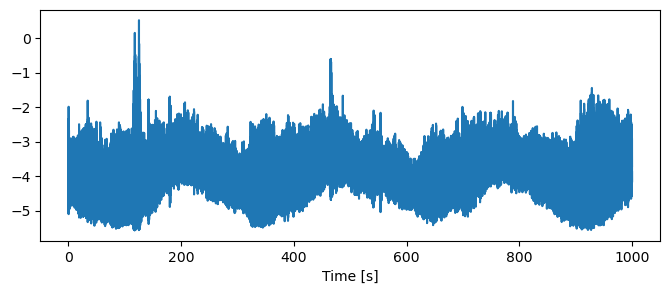

In [5]:
plt.figure(figsize=(8, 3))
plt.plot(rawdata[:, 0], rawdata[:, 1])
plt.xlabel('Time [s]')
plt.show()

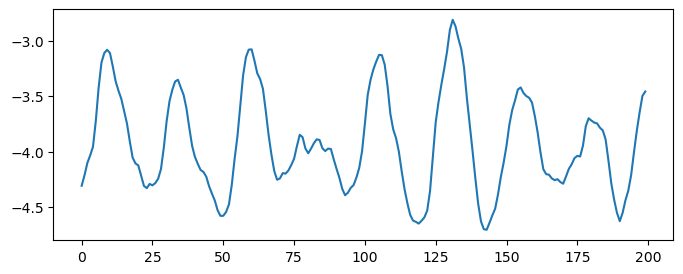

In [6]:

pos               = 400_100
nsample           = 1_000
detuning_stat1    = rawdata[pos:pos+nsample, [1]]

pos               = 626_200
nsample           = 1_000
detuning_stat2    = rawdata[pos:pos+nsample, [1]]

pos               = 700_200
nsample           = 1_000
detuning_stat3    = rawdata[pos:pos+nsample, [1]]

pos               = 709_800
nsample           = 1_000
detuning_stat4    = rawdata[pos:pos+nsample, [1]]

pos               = 100_000
nsample           = 1_000
detuning_stat5    = rawdata[pos:pos+nsample, [1]]

pos               = 900_000
nsample           = 1_000
detuning_stat6    = rawdata[pos:pos+nsample, [1]]

pos               = 804_000
nsample           = 1_000
detuning_trans1   = rawdata[pos:pos+nsample, [1]]

pos               = 120_000
nsample           = 1_000
detuning_trans2   = rawdata[pos:pos+nsample, [1]]

pos               = 170_000
nsample           = 1_000
detuning_trans3   = rawdata[pos:pos+nsample, [1]]

pos               = 200_000
nsample           = 1_000
detuning_trans4   = rawdata[pos:pos+nsample, [1]]

pos               = 220_000
nsample           = 1_000
detuning_trans5   = rawdata[pos:pos+nsample, [1]]

pos               = 404_000
nsample           = 200

rawdata_v         = rawdata[pos:pos+nsample, 1]

plt.figure(figsize=(8, 3))
plt.plot(rawdata_v)
plt.show()

In [7]:
# --! assemble stationary, transient and mixed datasets --!

detuning_stat = [
    detuning_stat1,
    detuning_stat2,
    detuning_stat3,
    detuning_stat4,
    detuning_stat5
]

detuning_trans = [
    detuning_trans1,
    detuning_trans2,
    detuning_trans3,
    detuning_trans4,
    detuning_trans5
]

detuning_mixed = detuning_stat + detuning_trans

In [8]:
datasaved = True

if datasaved:
    data_dir     = '../../data/baselines/train_tesla_stat'
    data_nsample = 100
    utils_data.save_traindata(detuning_stat, data_dir, data_nsample)

if datasaved:
    data_dir     = '../../data/baselines/train_tesla_trans'
    data_nsample = 100
    utils_data.save_traindata(detuning_trans, data_dir, data_nsample)

if datasaved:
    data_dir     = '../../data/baselines/train_tesla_mixed'
    data_nsample = 100
    utils_data.save_traindata(detuning_mixed, data_dir, data_nsample)

inf >> training files saved
inf >> training files saved
inf >> training files saved


In [9]:
# --! save timeseries
pos               = 404_000
nsample           = 1_000
detuning_test     = rawdata[pos:pos+nsample, [1]]

datasaved = True
if datasaved:
    data_dir     = '../../data/baselines/test_tesla'
    data_nsample = 100
    utils_data.save_testdata([detuning_test], data_dir, data_nsample)

inf >> evaluation file saved
